# 7CS353 Machine Learning Lab &mdash; Assignment 3
### Data Normalisation: Five Techniques and Their Visual Effects

**Name:** Atharv V Kulkarni
**PRN:** 245109074
**Class:** TY B.Tech CSE (B)

## Section 0: Dataset Generation

**Setup:** generate the fixed-seed dataset and save it to normalisation_data.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng=np.random.default_rng(seed=42)
n=200

bp=rng.normal(loc=120,scale=15,size=n).round(1)
wait=rng.gamma(shape=2,scale=30,size=n).round(1)

bp[rng.choice(n,5,replace=False)]=rng.uniform(190,230,5).round(1)
wait[rng.choice(n,5,replace=False)]=rng.uniform(350,500,5).round(1)

df=pd.DataFrame({"bp":bp,"wait":wait})
df.to_csv("normalisation_data.csv",index=False)
print(df.describe().round(2))
df.head()

           bp    wait
count  200.00  200.00
mean   121.72   72.46
std     18.72   74.97
min     88.00    2.80
25%    110.40   32.38
50%    119.80   54.75
75%    129.43   87.48
max    221.10  488.70


,bp,wait
0,124.6,64.2
1,104.4,53.6
2,131.3,5.2
3,134.1,23.9
4,90.7,23.1


## B.1 Generate and Explore the Raw Data

**B1:** load normalisation_data.csv and print shape, head and describe()

In [2]:
df=pd.read_csv("normalisation_data.csv")
print(df.shape)
print(df.head())
df.describe().round(2)

(200, 2)
      bp  wait
0  124.6  64.2
1  104.4  53.6
2  131.3   5.2
3  134.1  23.9
4   90.7  23.1


,bp,wait
count,200.00,200.00
mean,121.72,72.46
std,18.72,74.97
min,88.00,2.80
25%,110.40,32.38
50%,119.80,54.75
75%,129.43,87.48
max,221.10,488.70


**Solution:** bp has mean 121.72, median 119.80, min 88.0, max 221.1 - the mean sits above the
median by about 1.9. wait has mean 72.46, median 54.75, min 2.8, max 488.7 - the mean sits above the
median by about 17.7, a much bigger gap. a large gap between mean and median tells you the
distribution is not symmetric: the mean is pulled toward whichever side has the longer tail, so a mean
well above the median means a right-skewed shape with a small number of unusually high values dragging
the average up, while the median stays anchored to where most of the data actually sits.

**B2:** histogram and box plot of raw bp and raw wait side by side

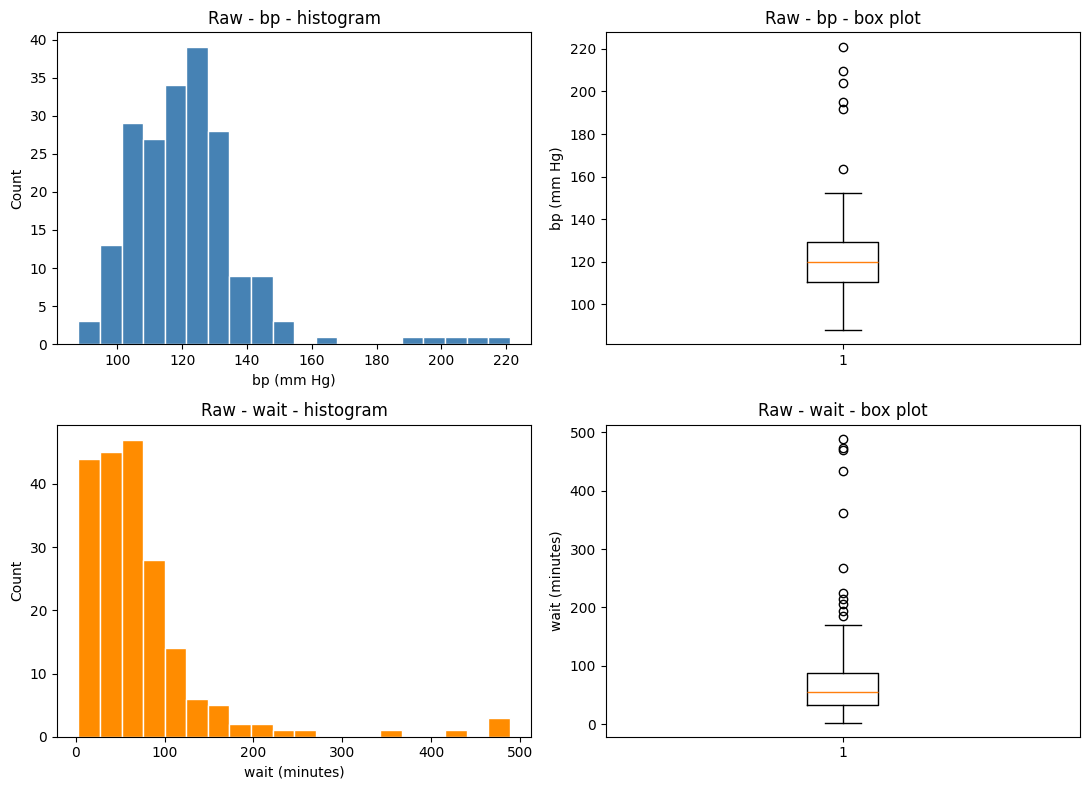

In [3]:
fig,ax=plt.subplots(2,2,figsize=(11,8))
ax[0,0].hist(df["bp"],bins=20,color="steelblue",edgecolor="white")
ax[0,0].set_title("Raw - bp - histogram")
ax[0,0].set_xlabel("bp (mm Hg)")
ax[0,0].set_ylabel("Count")
ax[0,1].boxplot(df["bp"])
ax[0,1].set_title("Raw - bp - box plot")
ax[0,1].set_ylabel("bp (mm Hg)")
ax[1,0].hist(df["wait"],bins=20,color="darkorange",edgecolor="white")
ax[1,0].set_title("Raw - wait - histogram")
ax[1,0].set_xlabel("wait (minutes)")
ax[1,0].set_ylabel("Count")
ax[1,1].boxplot(df["wait"])
ax[1,1].set_title("Raw - wait - box plot")
ax[1,1].set_ylabel("wait (minutes)")
plt.tight_layout()
plt.show()

**Solution:** bp looks far more symmetric, its histogram is a fairly even bell shape centred near
120. wait shows a clearly longer upper tail, most values are bunched below 100 minutes with a thin
spread of points stretching out past 300. outlier dots are visible above the top whisker in both box
plots, but the wait box plot's whisker is shorter relative to its outliers, making the outlier points
stand out more sharply above the box.

**B3:** skewness of both raw columns using pd.Series.skew()

In [4]:
print("bp skew:",df["bp"].skew())
print("wait skew:",df["wait"].skew())

bp skew: 2.2034292021486865
wait skew: 3.4447160606920275


**Solution:** bp has a skewness of about 2.20 and wait has a skewness of about 3.44. positive
skewness means the right tail of the distribution is longer than the left tail - most values are
concentrated on the low side and a few large values stretch the distribution out to the right, which is
exactly the shape a histogram with a long right tail shows visually. wait is more skewed than bp, and
that matches the plots in B2 - wait's histogram had the visibly longer, thinner tail on the right side
while bp looked close to a symmetric bell.

## B.2 Min Scaling ( x - min )

**B4:** apply min scaling to both columns and confirm every minimum is 0

In [5]:
bp_min=df["bp"]-df["bp"].min()
wait_min=df["wait"]-df["wait"].min()
print("bp_min range:",bp_min.min(),bp_min.max())
print("wait_min range:",wait_min.min(),wait_min.max())

bp_min range: 0.0 133.1
wait_min range: 0.0 485.9


**B5:** histogram and box plot after min scaling, for each column

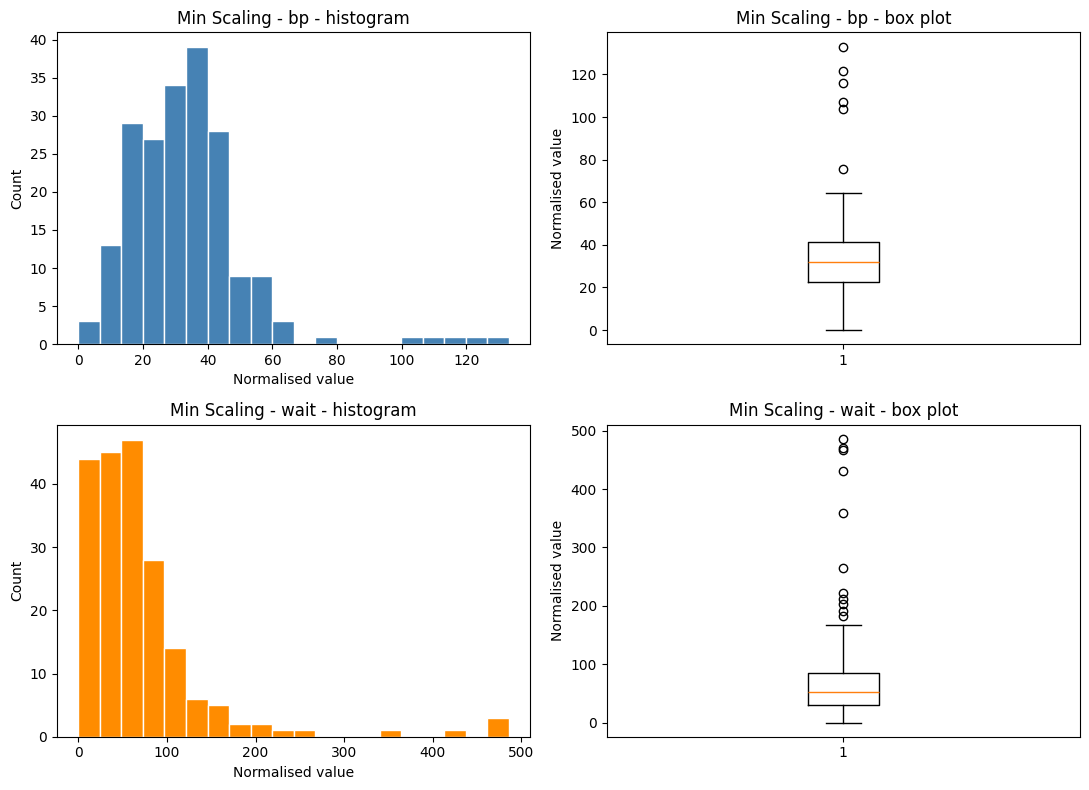

In [6]:
fig,ax=plt.subplots(2,2,figsize=(11,8))
ax[0,0].hist(bp_min,bins=20,color="steelblue",edgecolor="white")
ax[0,0].set_title("Min Scaling - bp - histogram")
ax[0,0].set_xlabel("Normalised value")
ax[0,0].set_ylabel("Count")
ax[0,1].boxplot(bp_min)
ax[0,1].set_title("Min Scaling - bp - box plot")
ax[0,1].set_ylabel("Normalised value")
ax[1,0].hist(wait_min,bins=20,color="darkorange",edgecolor="white")
ax[1,0].set_title("Min Scaling - wait - histogram")
ax[1,0].set_xlabel("Normalised value")
ax[1,0].set_ylabel("Count")
ax[1,1].boxplot(wait_min)
ax[1,1].set_title("Min Scaling - wait - box plot")
ax[1,1].set_ylabel("Normalised value")
plt.tight_layout()
plt.show()

**Solution:** for bp, the x-axis now starts at 0 and runs to about 133 instead of 88 to 221, but
the bell shape and spacing between bars stayed exactly the same. for wait, the x-axis now starts at 0
and runs to about 486 instead of 2.8 to 488.7, and again the right-skewed shape is completely
unchanged, only the numbers underneath moved.

**B6:** one situation where shifting the minimum to 0 is useful, and one limitation

**Solution:** shifting a distribution so its minimum is 0 is useful when a downstream calculation or
plot cannot handle negative numbers, for example if you want to treat the values as physical
quantities like a duration or a count where negative values would not make sense, min scaling
guarantees a non-negative starting point without touching the shape. the limitation is that it does not
control the overall scale at all - the maximum value still depends entirely on the outliers, so two
columns shifted this way can end up on very different numeric ranges and still cannot be compared
directly or fed into a distance-based model together.

## B.3 Max Scaling ( x / max )

**B7:** apply max scaling to both columns and print min and max

In [7]:
bp_max=df["bp"]/df["bp"].max()
wait_max=df["wait"]/df["wait"].max()
print("bp_max range:",bp_max.min(),bp_max.max())
print("wait_max range:",wait_max.min(),wait_max.max())

bp_max range: 0.39800995024875624 1.0
wait_max range: 0.005729486392469818 1.0


**Solution:** the minimum of bp_max is about 0.398, not 0, so it is not the same as the minimum of
bp_mm which will be exactly 0. max scaling only divides every value by the maximum, it never subtracts
anything, so whatever the smallest original value was, it simply gets divided down to smallest/max
rather than being shifted to 0.

**B8:** histogram and box plot after max scaling, for each column

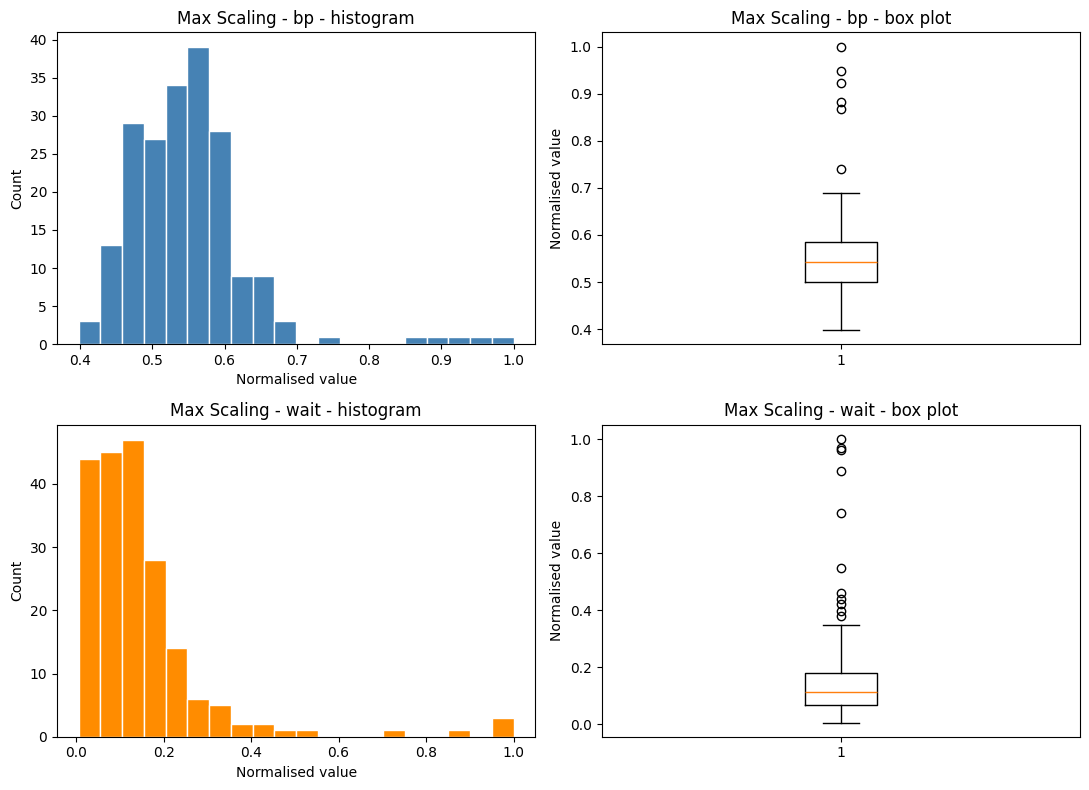

In [8]:
fig,ax=plt.subplots(2,2,figsize=(11,8))
ax[0,0].hist(bp_max,bins=20,color="steelblue",edgecolor="white")
ax[0,0].set_title("Max Scaling - bp - histogram")
ax[0,0].set_xlabel("Normalised value")
ax[0,0].set_ylabel("Count")
ax[0,1].boxplot(bp_max)
ax[0,1].set_title("Max Scaling - bp - box plot")
ax[0,1].set_ylabel("Normalised value")
ax[1,0].hist(wait_max,bins=20,color="darkorange",edgecolor="white")
ax[1,0].set_title("Max Scaling - wait - histogram")
ax[1,0].set_xlabel("Normalised value")
ax[1,0].set_ylabel("Count")
ax[1,1].boxplot(wait_max)
ax[1,1].set_title("Max Scaling - wait - box plot")
ax[1,1].set_ylabel("Normalised value")
plt.tight_layout()
plt.show()

**Solution:** compared with the min scaling plots, these histograms are squeezed into a much
narrower x-axis window since dividing by the maximum caps every value at 1 rather than spreading them
out from 0 upward. the minimum of the max-scaled column is not 0 because max scaling never subtracts
the minimum, it only divides by the largest value, so any originally positive minimum just becomes a
smaller positive fraction of the maximum instead of landing on 0.

## B.4 Min-Max Scaling ( (x - min) / (max - min) )

**B9:** apply min-max scaling to both columns and confirm min is 0 and max is 1

In [9]:
bp_mm=(df["bp"]-df["bp"].min())/(df["bp"].max()-df["bp"].min())
wait_mm=(df["wait"]-df["wait"].min())/(df["wait"].max()-df["wait"].min())
print("bp_mm range:",bp_mm.min(),bp_mm.max())
print("wait_mm range:",wait_mm.min(),wait_mm.max())

bp_mm range: 0.0 1.0
wait_mm range: 0.0 1.0


**B10:** histogram and box plot after min-max scaling, for each column

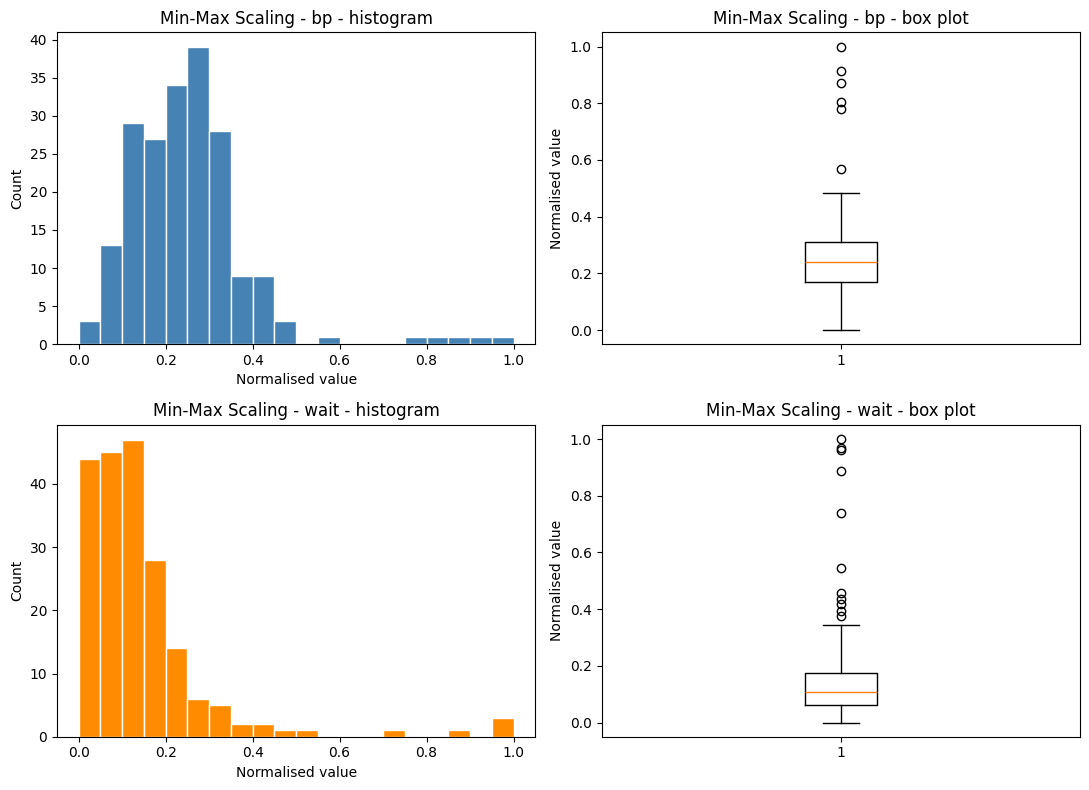

In [10]:
fig,ax=plt.subplots(2,2,figsize=(11,8))
ax[0,0].hist(bp_mm,bins=20,color="steelblue",edgecolor="white")
ax[0,0].set_title("Min-Max Scaling - bp - histogram")
ax[0,0].set_xlabel("Normalised value")
ax[0,0].set_ylabel("Count")
ax[0,1].boxplot(bp_mm)
ax[0,1].set_title("Min-Max Scaling - bp - box plot")
ax[0,1].set_ylabel("Normalised value")
ax[1,0].hist(wait_mm,bins=20,color="darkorange",edgecolor="white")
ax[1,0].set_title("Min-Max Scaling - wait - histogram")
ax[1,0].set_xlabel("Normalised value")
ax[1,0].set_ylabel("Count")
ax[1,1].boxplot(wait_mm)
ax[1,1].set_title("Min-Max Scaling - wait - box plot")
ax[1,1].set_ylabel("Normalised value")
plt.tight_layout()
plt.show()

**Solution:** the outlier dots on both box plots sit very close to 1.0, squashed right up against
the top of the [0,1] range. this does look more compressed toward the high end than the z-score and IQR
plots will look later, since here the single largest outlier defines the entire top of the scale and
everything else gets crammed into whatever room is left below it - noted, to revisit in B.7.

**B11:** why min-max scaling is sensitive to outliers

**Solution:** min-max scaling is sensitive to outliers because the entire [0,1] range is defined by
just two numbers, the minimum and the maximum, so a single extreme value completely determines where 1.0
falls. if a value of 10,000 were added to the wait column, the new maximum would jump from about 489 to
10,000, and every existing non-outlier value would be divided by a denominator roughly twenty times
larger than before - all of them would collapse into a tiny sliver near 0, destroying the resolution
between typical waiting times that used to be spread out across the full [0,1] range.

## B.5 Z-Score Normalisation ( (x - mean) / std )

**B12:** apply z-score normalisation to both columns, print mean and std of the result

In [11]:
bp_z=(df["bp"]-df["bp"].mean())/df["bp"].std()
wait_z=(df["wait"]-df["wait"].mean())/df["wait"].std()
print("bp_z mean and std:",bp_z.mean(),bp_z.std())
print("wait_z mean and std:",wait_z.mean(),wait_z.std())

bp_z mean and std: 3.7747582837255325e-17 0.9999999999999999
wait_z mean and std: 8.881784197001253e-18 1.0


**Solution:** the printed mean is not exactly 0, it is a tiny number like 3.8e-17, and the std comes
out as almost exactly 1. they are not exactly 0 and 1 because computers store decimal numbers in binary
floating point, which cannot represent most decimal fractions perfectly, so tiny rounding errors from
all the subtractions and divisions accumulate into a value that is mathematically zero but numerically
just a hair off.

**B13:** histogram and box plot after z-score normalisation, for each column

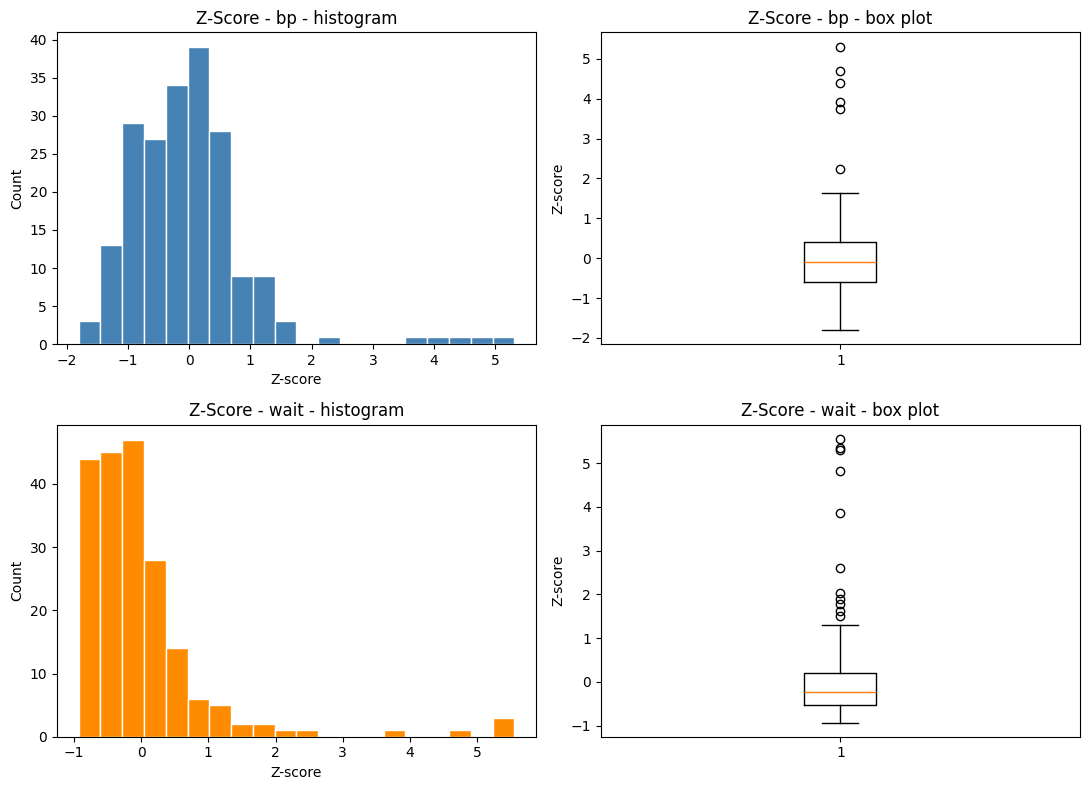

In [12]:
fig,ax=plt.subplots(2,2,figsize=(11,8))
ax[0,0].hist(bp_z,bins=20,color="steelblue",edgecolor="white")
ax[0,0].set_title("Z-Score - bp - histogram")
ax[0,0].set_xlabel("Z-score")
ax[0,0].set_ylabel("Count")
ax[0,1].boxplot(bp_z)
ax[0,1].set_title("Z-Score - bp - box plot")
ax[0,1].set_ylabel("Z-score")
ax[1,0].hist(wait_z,bins=20,color="darkorange",edgecolor="white")
ax[1,0].set_title("Z-Score - wait - histogram")
ax[1,0].set_xlabel("Z-score")
ax[1,0].set_ylabel("Count")
ax[1,1].boxplot(wait_z)
ax[1,1].set_title("Z-Score - wait - box plot")
ax[1,1].set_ylabel("Z-score")
plt.tight_layout()
plt.show()

**Solution:** the outlier dots on the bp box plot sit up around z is approximately 3 to 5.3, and on
the wait box plot they run up to about z is approximately 5.6 - both sets of outliers land well beyond
+3. a z-score of +4 in plain language means that value is 4 standard deviations above the average, in a
roughly normal distribution that is an extremely rare reading, far outside the range where almost all
of the typical data falls.

**B14:** compare the z-score histogram of bp with its raw histogram from B.1

**Solution:** the bell shape of the bp histogram is unchanged after z-scoring, but the x-axis scale
changed completely - it used to run from about 88 to 221 in mm Hg, and now it runs from about -1.8 to
5.3 in standard-deviation units centred on 0, so the same bell just slid over so its centre sits at zero
instead of at 120.

## B.6 IQR / Robust Scaling ( (x - median) / IQR )

**B15:** apply IQR scaling to both columns, print median and IQR of the result, verify median is 0

In [13]:
Q1_bp,Q3_bp=df["bp"].quantile(0.25),df["bp"].quantile(0.75)
Q1_wait,Q3_wait=df["wait"].quantile(0.25),df["wait"].quantile(0.75)
bp_iqr=(df["bp"]-df["bp"].median())/(Q3_bp-Q1_bp)
wait_iqr=(df["wait"]-df["wait"].median())/(Q3_wait-Q1_wait)
print("bp_iqr median:",bp_iqr.median(),"IQR value:",Q3_bp-Q1_bp)
print("wait_iqr median:",wait_iqr.median(),"IQR value:",Q3_wait-Q1_wait)

bp_iqr median: -3.7339922820400773e-16 IQR value: 19.025000000000006
wait_iqr median: 0.0 IQR value: 55.099999999999994


**B16:** histogram and box plot after IQR scaling, for each column

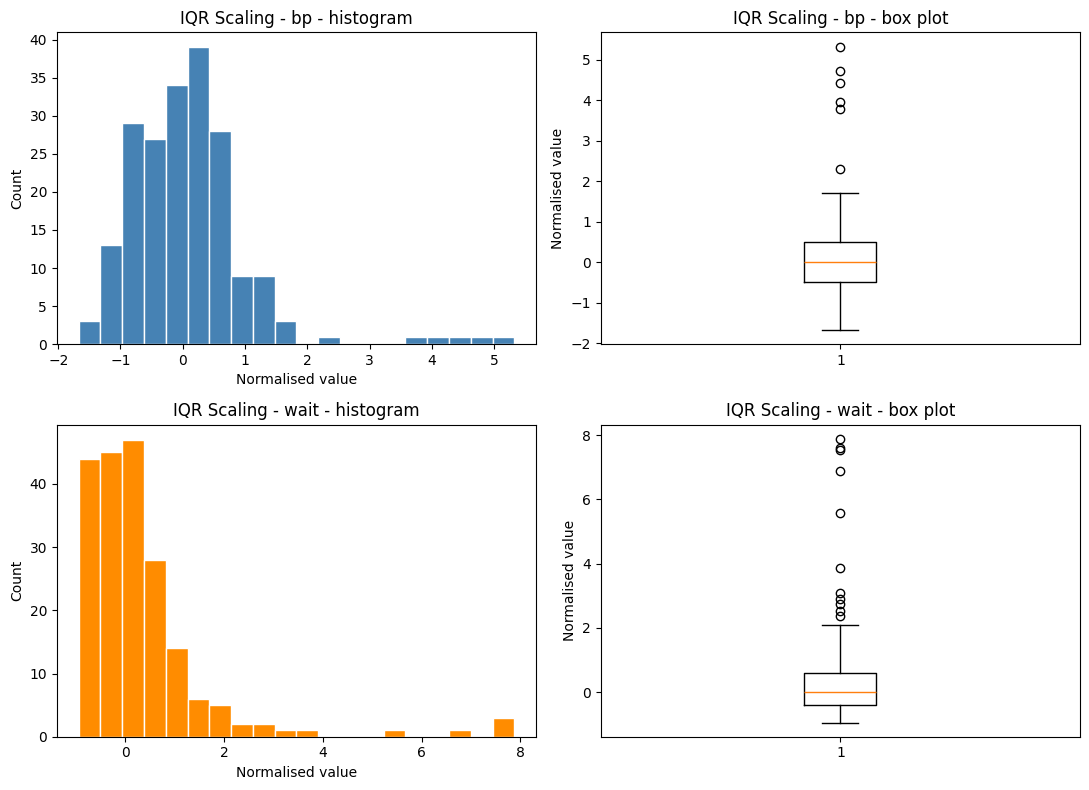

In [14]:
fig,ax=plt.subplots(2,2,figsize=(11,8))
ax[0,0].hist(bp_iqr,bins=20,color="steelblue",edgecolor="white")
ax[0,0].set_title("IQR Scaling - bp - histogram")
ax[0,0].set_xlabel("Normalised value")
ax[0,0].set_ylabel("Count")
ax[0,1].boxplot(bp_iqr)
ax[0,1].set_title("IQR Scaling - bp - box plot")
ax[0,1].set_ylabel("Normalised value")
ax[1,0].hist(wait_iqr,bins=20,color="darkorange",edgecolor="white")
ax[1,0].set_title("IQR Scaling - wait - histogram")
ax[1,0].set_xlabel("Normalised value")
ax[1,0].set_ylabel("Count")
ax[1,1].boxplot(wait_iqr)
ax[1,1].set_title("IQR Scaling - wait - box plot")
ax[1,1].set_ylabel("Normalised value")
plt.tight_layout()
plt.show()

**Solution:** on the wait column the IQR-scaled outliers reach out to about 7.9, farther than the
z-scaled outliers at about 5.6, while on bp the two methods land at a similar distance since bp is much
less skewed. IQR scaling divides by the interquartile range instead of the full standard deviation, and
because the interquartile range only measures the spread of the middle 50% of the data it stays small
even when a few outliers are huge, so those same outliers get divided by a small number and are pushed
out much farther, while the bulk of ordinary points - which the IQR was measured from - stays compact.

**B17:** compare the IQR-scaled and z-score-scaled box plots of wait side by side

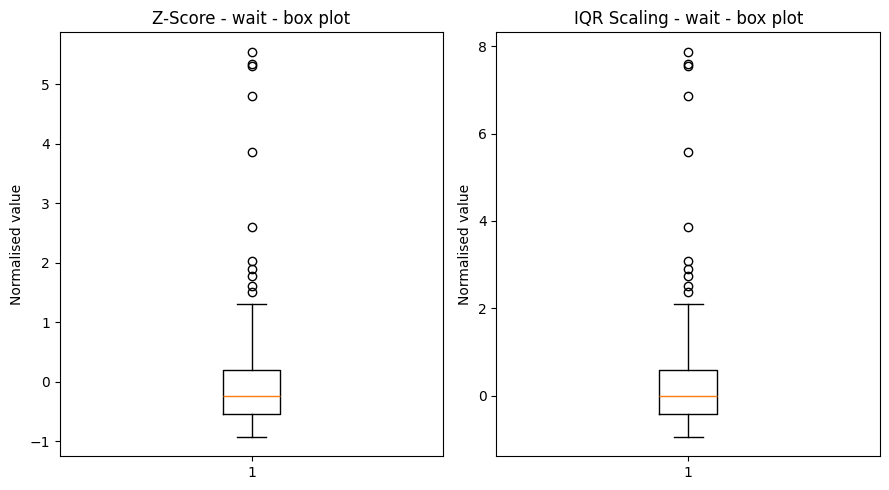

In [15]:
fig,ax=plt.subplots(1,2,figsize=(9,5))
ax[0].boxplot(wait_z)
ax[0].set_title("Z-Score - wait - box plot")
ax[0].set_ylabel("Normalised value")
ax[1].boxplot(wait_iqr)
ax[1].set_title("IQR Scaling - wait - box plot")
ax[1].set_ylabel("Normalised value")
plt.tight_layout()
plt.show()

**Solution:** for a dataset with many extreme outliers, IQR / robust scaling would be preferred over
z-score, because the standard deviation used in z-scoring is itself inflated by the outliers, which
compresses the bulk of the normal data slightly toward the centre, while the median and interquartile
range used in robust scaling are barely affected by extreme values, so the everyday data keeps a more
faithful, spread-out shape and the outliers are the ones pushed out to signal that they are unusual.

## B.7 Summary Comparison

**B18:** single DataFrame with raw bp and all five normalised versions, describe() on it

In [16]:
summary=pd.DataFrame({
    "raw":df["bp"],
    "min_scale":bp_min,
    "max_scale":bp_max,
    "min_max":bp_mm,
    "z":bp_z,
    "iqr":bp_iqr
})
summary.describe().round(3)

,raw,min_scale,max_scale,min_max,z,iqr
count,200.000,200.000,200.000,200.000,200.000,200.000
mean,121.723,33.723,0.551,0.253,0.000,0.101
std,18.717,18.717,0.085,0.141,1.000,0.984
min,88.000,0.000,0.398,0.000,-1.802,-1.671
25%,110.400,22.400,0.499,0.168,-0.605,-0.494
50%,119.800,31.800,0.542,0.239,-0.103,-0.000
75%,129.425,41.425,0.585,0.311,0.411,0.506
max,221.100,133.100,1.000,1.000,5.309,5.325


**Solution:**

| Technique | min | max | mean | median |
|---|---|---|---|---|
| raw | 88.00 | 221.10 | 121.72 | 119.80 |
| min scale | 0.00 | 133.10 | 33.72 | 31.80 |
| max scale | 0.40 | 1.00 | 0.55 | 0.54 |
| min-max | 0.00 | 1.00 | 0.25 | 0.24 |
| z-score | -1.80 | 5.31 | 0.00 | -0.10 |
| iqr | -1.67 | 5.32 | 0.10 | 0.00 |

min scaling and max scaling produce the same shape as the raw data with only the x-axis scale changed -
min scaling just shifts everything so the minimum sits at 0, and max scaling just compresses everything
so the maximum sits at 1, but neither one changes the relative spacing between points, so their
histograms are stretched or compressed copies of the raw histogram rather than reshaped ones.

**B19:** one figure with five box plots side by side for the wait column

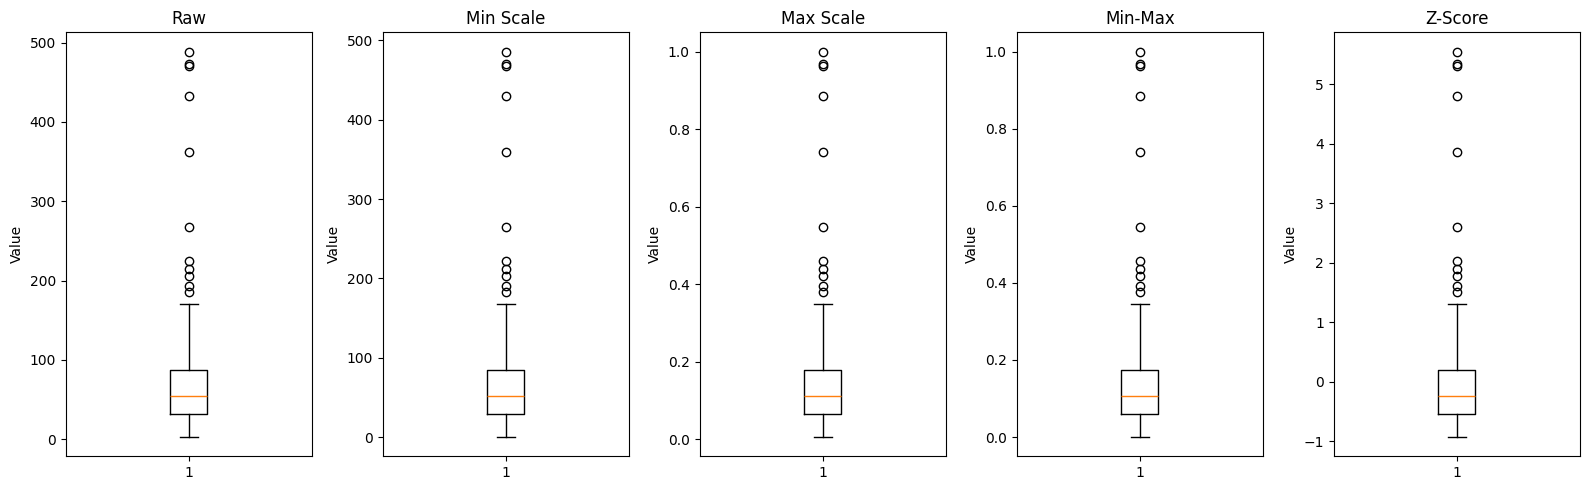

In [17]:
fig,ax=plt.subplots(1,5,figsize=(16,5))
techniques=[("Raw",df["wait"]),("Min Scale",wait_min),("Max Scale",wait_max),("Min-Max",wait_mm),("Z-Score",wait_z)]
for a,(name,data) in zip(ax,techniques):
    a.boxplot(data)
    a.set_title(name)
    a.set_ylabel("Value")
plt.tight_layout()
plt.show()

**Solution:** min-max scaling most compresses the main body of the data, since it squeezes almost
every ordinary point into a thin band near the bottom of the [0,1] range once the far outlier defines
the top. z-score normalisation makes the outliers look the most extreme relative to the box, since the
main body clusters tightly around 0 while the outliers stretch out to roughly +5, visually the farthest
detached points of any of the five techniques shown here.

**B20:** which normalisation technique for an outlier-sensitive, scale-sensitive model like K-NN

**Solution:** for a distance-based model like K-NN on data that contains outliers, IQR / robust
scaling is the better default choice over min-max scaling. min-max scaling anchors the entire [0,1] range
to the single smallest and largest values, so one extreme outlier can silently compress every ordinary
point into a narrow band, making K-NN's distance calculations lose most of their ability to
discriminate between typical cases. z-score is a reasonable middle ground, since it centres the data
around 0, but its scale still depends on the standard deviation which outliers inflate. robust scaling
uses the median and interquartile range instead, both of which barely move when a few extreme points
are present, so the bulk of the data keeps a stable, well-spread-out scale and the outliers, rather than
distorting everyone else, are simply the ones that end up flagged with unusually large normalised
values. that combination of stability for normal points and honesty about which points are unusual is
exactly what a distance-based model needs.

## B.8 Take-Home

**B21:** generate a bimodal column, apply all five normalisations, histogram each

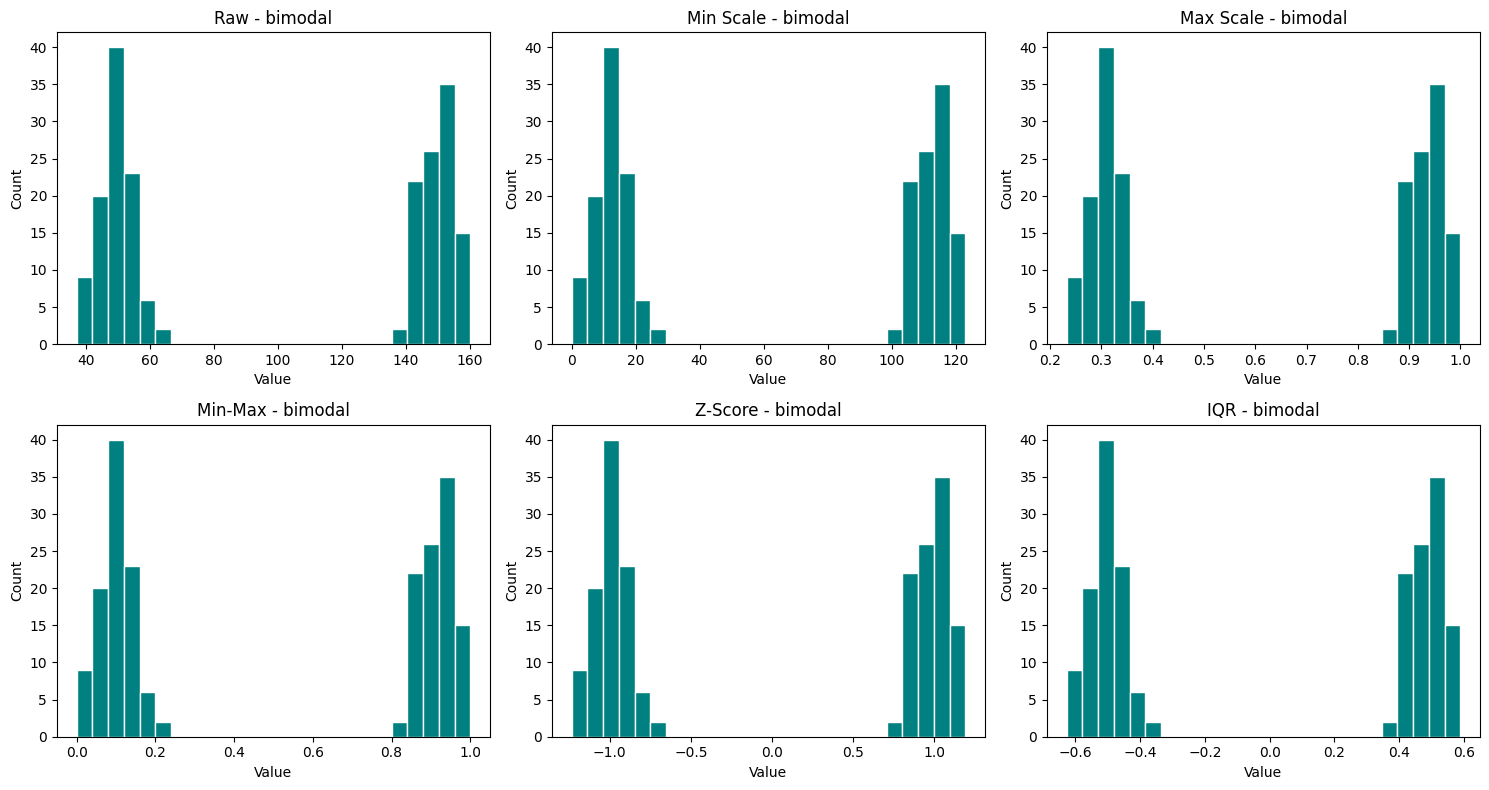

In [18]:
bimodal=np.concatenate([rng.normal(50,5,100),rng.normal(150,5,100)])
bm=pd.Series(bimodal,name="bimodal")
bm_min=bm-bm.min()
bm_max=bm/bm.max()
bm_mm=(bm-bm.min())/(bm.max()-bm.min())
bm_z=(bm-bm.mean())/bm.std()
Q1_bm,Q3_bm=bm.quantile(0.25),bm.quantile(0.75)
bm_iqr=(bm-bm.median())/(Q3_bm-Q1_bm)
fig,ax=plt.subplots(2,3,figsize=(15,8))
plots=[("Raw",bm),("Min Scale",bm_min),("Max Scale",bm_max),("Min-Max",bm_mm),("Z-Score",bm_z),("IQR",bm_iqr)]
for a,(name,data) in zip(ax.flatten(),plots):
    a.hist(data,bins=25,color="teal",edgecolor="white")
    a.set_title(name+" - bimodal")
    a.set_xlabel("Value")
    a.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Solution:** min scaling, max scaling, min-max scaling, z-score and IQR scaling all preserve the
two separate humps just as clearly as the raw histogram, since every one of these five techniques is a
simple linear transformation that only shifts or stretches the x-axis without moving points relative to
each other - none of them would be misleading about the bimodal shape. the only way a normalisation
could hide the two humps would be a non-linear transform like a log or a rank-based transform that warps
distances between points unevenly, which none of these five techniques do.

**B22:** custom min_max_scale and z_score_scale functions using only basic arithmetic

In [19]:
def min_max_scale(arr):
    lo=arr[0]
    hi=arr[0]
    for x in arr:
        if x<lo:
            lo=x
        if x>hi:
            hi=x
    result=[]
    for x in arr:
        result.append((x-lo)/(hi-lo))
    return result

def z_score_scale(arr):
    n=len(arr)
    total=0
    for x in arr:
        total+=x
    mean=total/n
    sq=0
    for x in arr:
        sq+=(x-mean)**2
    std=(sq/(n-1))**0.5
    result=[]
    for x in arr:
        result.append((x-mean)/std)
    return result

bp_list=df["bp"].tolist()
my_mm=min_max_scale(bp_list)
my_z=z_score_scale(bp_list)
pandas_mm=((df["bp"]-df["bp"].min())/(df["bp"].max()-df["bp"].min())).tolist()
pandas_z=((df["bp"]-df["bp"].mean())/df["bp"].std()).tolist()
print("min-max match:",np.allclose(my_mm,pandas_mm))
print("z-score match:",np.allclose(my_z,pandas_z))

min-max match: True
z-score match: True


**B23:** explore log transformation

wait skew before log: 3.4447160606920275 after log: -0.3376416945024374
bp skew before log: 2.2034292021486865 after log: 1.2220378499444773


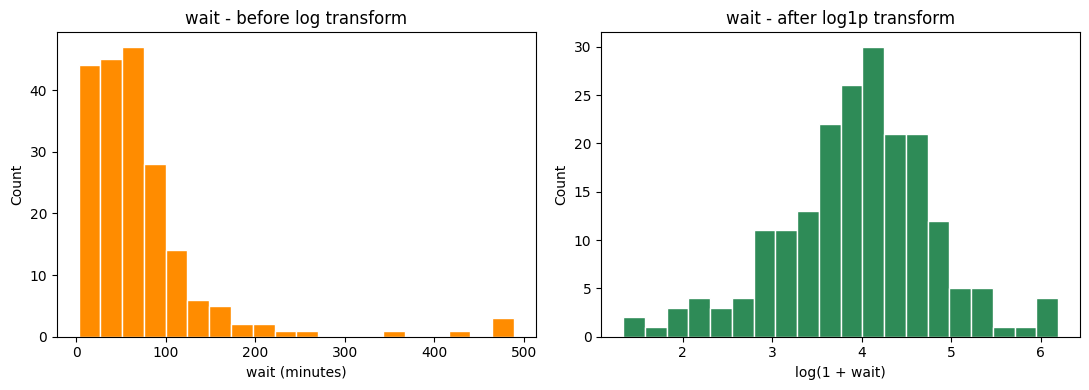

In [20]:
log_wait=np.log1p(df["wait"])
log_bp=np.log1p(df["bp"])
print("wait skew before log:",df["wait"].skew(),"after log:",log_wait.skew())
print("bp skew before log:",df["bp"].skew(),"after log:",log_bp.skew())
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].hist(df["wait"],bins=20,color="darkorange",edgecolor="white")
ax[0].set_title("wait - before log transform")
ax[0].set_xlabel("wait (minutes)")
ax[0].set_ylabel("Count")
ax[1].hist(log_wait,bins=20,color="seagreen",edgecolor="white")
ax[1].set_title("wait - after log1p transform")
ax[1].set_xlabel("log(1 + wait)")
ax[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

**Solution:** log transformation is a non-linear operation, unlike the five linear scalers used
above, and it visibly reshapes the distribution rather than just rescaling the axis. applying log1p to
wait drops its skewness from about 3.44 down to about -0.34, turning a long right-tailed shape into
something close to symmetric, because the log compresses large values much more than small ones and so
pulls in the long right tail specifically. applying the same transform to bp only drops skewness from
about 2.20 to about 1.22, a smaller improvement, since bp was never as extremely right-skewed to begin
with - log transformation helps most exactly where the raw skew is worst.